# Window function construction in k-space

This notebook illustrates how the power spectrum window function is constructed consecutively. The formalism is detailed in the [API summary](https://meer21cm.readthedocs.io/en/latest/meer21cm.html#module-meer21cm.smooth_window).

In short, there are three levels of window function we need to calculate for the survey:
1. A transformation of survey window (combined weights) onto multipoles, $W_L(k)$.
2. From the window multipoles, the continuous response function $W_{L\ell'}(k,k')$
3. From the continuous response function, combined with the exact k-binning and discrete sampling, the final window function $W_{\ell i,\,\ell' j}$

The final step and its effect are separately discussed in [this cookbook](https://meer21cm.readthedocs.io/en/latest/cookbook/discrete_k_sampling.html) as well.

Note that, each step corresponds to a different level of $k$-sampling.
The final $W_{\ell i,\,\ell' j}$ must have $k_i$ as the same k-bin as the measured multipole, which is typically coarser and in a smaller range. $k_j$ on the other hand, is the one that operates on the theory model, which typically is finer and has a larger range. This results in 3 different k-bins:

1. $k_{\mathrm{window}}$ — fine `k1dbins_window` used only to measure $W_L(k)$ from the selection.
2. $k_{\mathrm{in}}$ — fine theory nodes for $P_{\ell'}(k_{\mathrm{in}})$.
3. $k_{\mathrm{out}}$ — coarse estimator bins (`k1dbins_out` / global plane-parallel `ps.k1dbins`).

Let's understand the k-sampling by first constructing a naive simulation under global plane-parallel, and use tapers as weights:

In [2]:
import warnings

import numpy as np
import matplotlib.pyplot as plt

from meer21cm import MockSimulation
from meer21cm.multipole_model import SmoothWindowEstimator
from meer21cm.util import redshift_to_freq
from meer21cm.smooth_window import build_discrete_shell_window_matrix


# build simple simulation
z_min, z_max = 0.6, 0.8
nu_arr = np.linspace(redshift_to_freq(z_max), redshift_to_freq(z_min), 100)
mock = MockSimulation(
    ra_range=(0, 20),
    dec_range=(-20, 20),
    nu=nu_arr,
    hp_nside=128,
    mean_amp_1=1.0,
    include_beam=[False, False],
    include_sky_sampling=[False, False],
    compensate=[False, False],
    sigma_v_1=200,
    density='gaussian',
)
mock.k1dbins = np.linspace(0.01, 0.25, 11)
mock.field_1 = mock.mock_tracer_field_1
mock.weights_1 = np.ones_like(mock.field_1)
# taper the field with a default Blackmann-Harris window
mock.apply_taper_to_field(1, axis=(0, 1, 2))



In the global plane-parallel, we don't need to calculate window function.
Instead, we can just convolve the weights with the power spectrum at 3D k-grid
and bin it into 1D. We will just that as the benchmark:

In [3]:
# get the 3D to 1D exact averaging
ells = (0, 2, 4)
k1dbins = mock.k1dbins
# get the shell index for each k-bin, used for later
shell = mock.multipole_bin_index_map(k1dbins=k1dbins)

# Direct averaging of 3D into 1D
p3d_model = mock.auto_power_tracer_1_model
p3d_mock = mock.auto_power_3d_1
P_disc_model = {}
P_disc_mock = {}
for ell in ells:
    P_disc_model[ell], keff_disc, _ = mock.get_1d_power(p3d_model, multipole_ell=ell)
    P_disc_mock[ell], keff_disc, _ = mock.get_1d_power(p3d_mock, multipole_ell=ell)


The model and mock agree within cosmic variance:

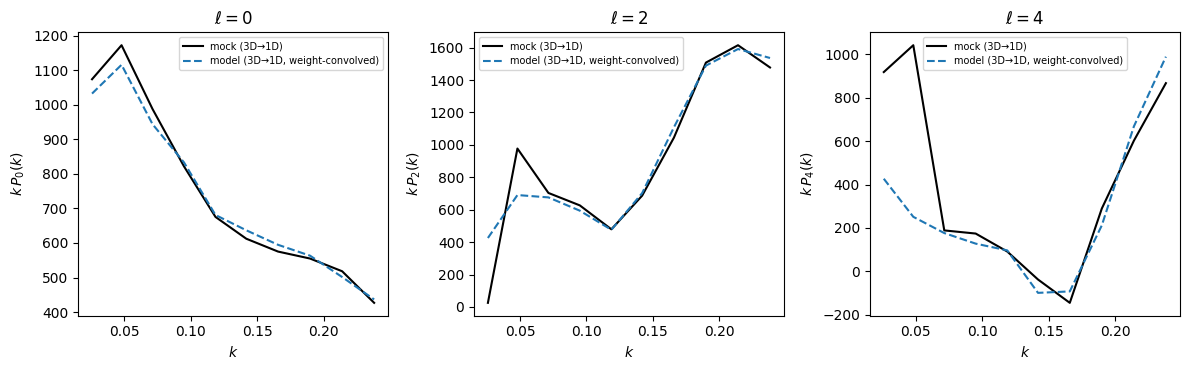

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True)
for ax, ell in zip(axes, ells):
    ax.plot(keff_disc, P_disc_mock[ell] * keff_disc, "k-", lw=1.5, label="mock (3D→1D)")
    ax.plot(
        keff_disc,
        P_disc_model[ell] * keff_disc,
        "C0--",
        lw=1.5,
        label=r"model (3D→1D, weight-convolved)",
    )
    ax.set_xlabel(r"$k$")
    ax.set_ylabel(r"$k\,P_%d(k)$" % ell)
    ax.legend(fontsize=7)
    ax.set_title(r"$\ell=%d$" % ell)
fig.tight_layout()


Now let's do the alternative route of calculating the spherically averaged theoretical multipoles, matrix multiply the window function to the theory multipoles, to get to the final output model multipoles that incorporate the discrete sampling and grid tapering.

As listed above, the first step is to calculate the window multipoles:

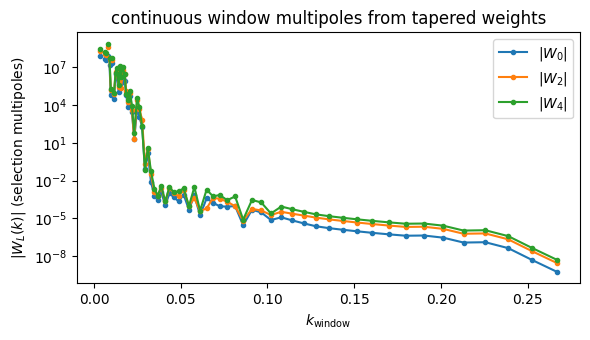

In [21]:
# Measure W_L on fine k1dbins_window; ensure enough sampling in low-k
k1dbins_window = np.geomspace(
    max(float(mock.k1dbins[0]) * 0.1, 1e-3),
    float(mock.k1dbins[-1]) * 1.1,
    100,
)
swe = SmoothWindowEstimator.from_power_spectrum(
    mock,
    tracer="hi",
    ells=ells,
    weights_hi=mock.weights_1,
    weights_grid_1=None,  # avoid double-counting: weights_hi is already the full taper
    k1dbins_window=k1dbins_window,
    k1dbins_out=mock.k1dbins,
)
swe.accumulate([swe.run_one(0)])

fig, ax = plt.subplots(figsize=(6, 3.5))
for ell in ells:
    ax.semilogy(swe.k_window, np.abs(swe.W_ell[ell]), "-o", ms=3, label=rf"$|W_{ell}|$")
ax.set_xlabel(r"$k_{\mathrm{window}}$")
ax.set_ylabel(r"$|W_L(k)|$ (selection multipoles)")
ax.legend()
ax.set_title("continuous window multipoles from tapered weights")
fig.tight_layout()


Essentially, you can think of $W_L(k)$ as the multipole power spectrum for the weights. Therefore, the taper is behaving as expected. It is a narrow window in k, whose power concentrates around 0. Suppose instead you use a coarse bin:

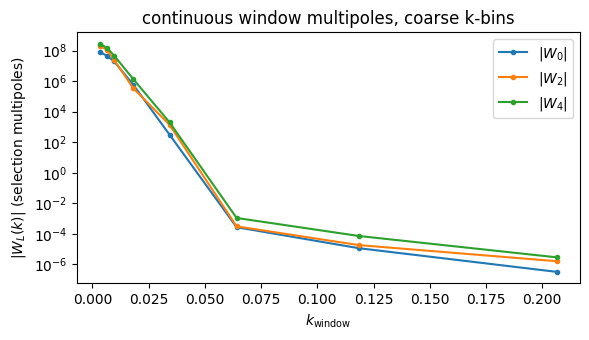

In [22]:
# Measure W_L on fine k1dbins_window; ensure enough sampling in low-k
k1dbins_window2 = np.geomspace(
    max(float(mock.k1dbins[0]) * 0.1, 1e-3),
    float(mock.k1dbins[-1]) * 1.1,
    10,
)
swe2 = SmoothWindowEstimator.from_power_spectrum(
    mock,
    tracer="hi",
    ells=ells,
    weights_hi=mock.weights_1,
    weights_grid_1=None,  # avoid double-counting: weights_hi is already the full taper
    k1dbins_window=k1dbins_window2,
    k1dbins_out=mock.k1dbins,
)
swe2.accumulate([swe2.run_one(0)])

fig, ax = plt.subplots(figsize=(6, 3.5))
for ell in ells:
    ax.semilogy(swe2.k_window, np.abs(swe2.W_ell[ell]), "-o", ms=3, label=rf"$|W_{ell}|$")
ax.set_xlabel(r"$k_{\mathrm{window}}$")
ax.set_ylabel(r"$|W_L(k)|$ (selection multipoles)")
ax.legend()
ax.set_title("continuous window multipoles, coarse k-bins")
fig.tight_layout()


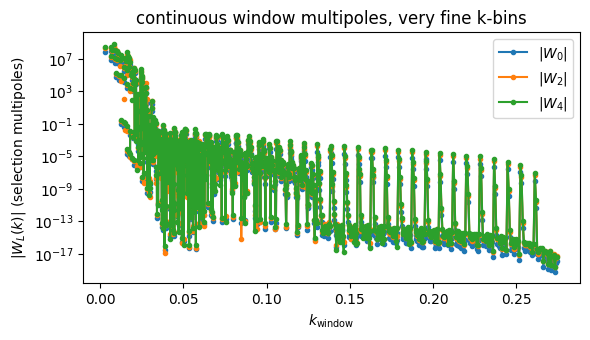

In [26]:
# Measure W_L on fine k1dbins_window; ensure enough sampling in low-k
k1dbins_window3 = np.geomspace(
    max(float(mock.k1dbins[0]) * 0.1, 1e-3),
    float(mock.k1dbins[-1]) * 1.1,
    2000,
)
swe3 = SmoothWindowEstimator.from_power_spectrum(
    mock,
    tracer="hi",
    ells=ells,
    weights_hi=mock.weights_1,
    weights_grid_1=None,  # avoid double-counting: weights_hi is already the full taper
    k1dbins_window=k1dbins_window3,
    k1dbins_out=mock.k1dbins,
)
swe3.accumulate([swe3.run_one(0)])

fig, ax = plt.subplots(figsize=(6, 3.5))
for ell in ells:
    ax.semilogy(swe3.k_window, np.abs(swe3.W_ell[ell]), "-o", ms=3, label=rf"$|W_{ell}|$")
ax.set_xlabel(r"$k_{\mathrm{window}}$")
ax.set_ylabel(r"$|W_L(k)|$ (selection multipoles)")
ax.legend()
ax.set_title("continuous window multipoles, very fine k-bins")
fig.tight_layout()


You can see that for the coarse k-bins, even though structures appear to be smoother, the sampling at low $k$ is not dense enough, which may lead to numerical biases for the integration later.

So let's then build the rest of the window matrix:

In [40]:
# the dense theory k-grids
k_in = np.geomspace(max(float(k1dbins[0]) * 0.5, 1e-3), float(k1dbins[-1]) * 1.5, 50)

# Smooth continuous kernel + discrete shells
mat_smooth = swe.build_window_matrix(
    k_in,
    shell_map=shell,
    continuous="smooth",
    n_fftlog=256,
    n_k_eval=128,
)

mat_smooth2 = swe2.build_window_matrix(
    k_in,
    shell_map=shell,
    continuous="smooth",
    n_fftlog=256,
    n_k_eval=128,
)

mat_smooth3 = swe3.build_window_matrix(
    k_in,
    shell_map=shell,
    continuous="smooth",
    n_fftlog=256,
    n_k_eval=128,
)

# get the unconvolved theory
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    cont_fine = mock.get_theory_multipoles_kmu(k_in, ells=ells, nmu=64, which="auto_1")

P_win_smooth = mat_smooth.apply(cont_fine["P_ell"])
P_win_smooth2 = mat_smooth2.apply(cont_fine["P_ell"])
P_win_smooth3 = mat_smooth3.apply(cont_fine["P_ell"])

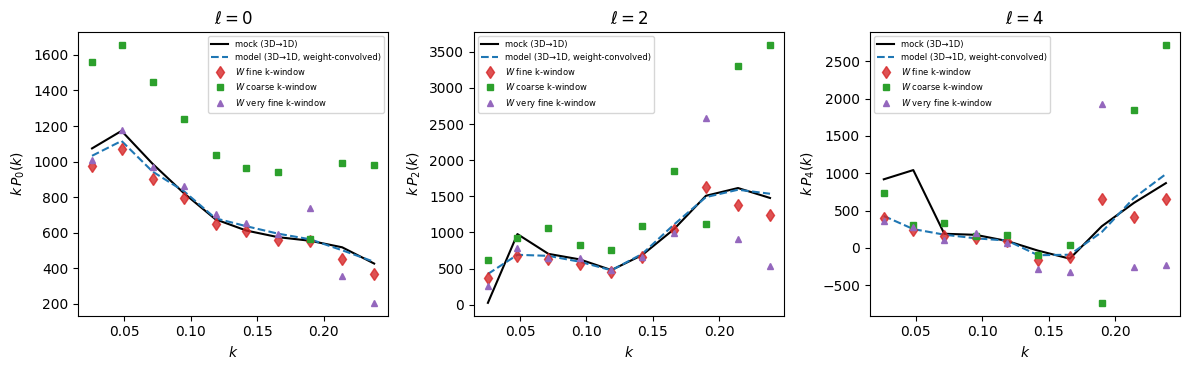

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True)
for ax, ell in zip(axes, ells):
    ax.plot(keff_disc, P_disc_mock[ell] * keff_disc, "k-", lw=1.5, label="mock (3D→1D)")
    ax.plot(
        keff_disc,
        P_disc_model[ell] * keff_disc,
        "C0--",
        lw=1.5,
        label=r"model (3D→1D, weight-convolved)",
    )
    ax.plot(
        mat_smooth.k_out,
        P_win_smooth[ell] * mat_smooth.k_out,
        "C3d",
        lw=1.0,
        alpha=0.8,
        label=r"$W$ fine k-window",
    )
    ax.plot(
        mat_smooth2.k_out,
        P_win_smooth2[ell] * mat_smooth2.k_out,
        "C2s",
        ms=5,
        label=r"$W$ coarse k-window",
    )
    ax.plot(
        mat_smooth3.k_out,
        P_win_smooth3[ell] * mat_smooth3.k_out,
        "C4^",
        ms=5,
        label=r"$W$ very fine k-window",
    )
    ax.set_xlabel(r"$k$")
    ax.set_ylabel(r"$k\,P_%d(k)$" % ell)
    ax.legend(fontsize=6)
    ax.set_title(r"$\ell=%d$" % ell)
fig.tight_layout()


You can see that the coarse window is not normalised correctly, because we are missing the sampling in low $k$ where the window multipole powers concentrate.

Still, the accuracy is not great on large k.
This is because we haven't examined `k_in`, which is the theory k-grids used.
In the above script, we are setting `k_in` to be log-spaced.
Log-spaced is great for $W_L$, because it relies on Hankel transformation that naturally lives in FFTlog space.
But for theory, log-spacing gives very sparse sampling at large $k$. It is much better to use linear k-binning for `k-in`:

In [44]:
# the dense theory k-grids in linear spacing
k_in_alt = np.linspace(max(float(k1dbins[0]) * 0.5, 1e-3), float(k1dbins[-1]) * 1.5, 500)

# only look at very fine k-bins
mat_smooth3_alt = swe3.build_window_matrix(
    k_in_alt,
    shell_map=shell,
    continuous="smooth",
    n_fftlog=256,
    n_k_eval=128,
)

# get the unconvolved theory
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    cont_fine_alt = mock.get_theory_multipoles_kmu(k_in_alt, ells=ells, nmu=64, which="auto_1")


P_win_smooth3_alt = mat_smooth3_alt.apply(cont_fine_alt["P_ell"])

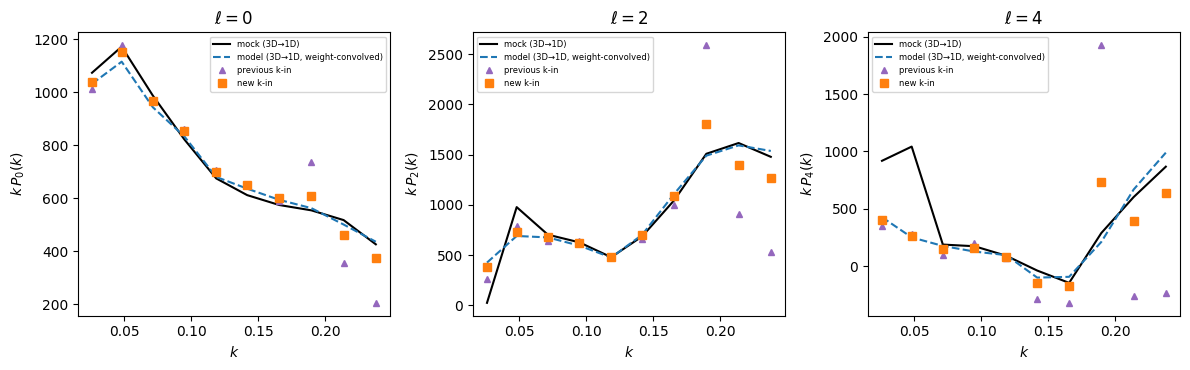

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True)
for ax, ell in zip(axes, ells):
    ax.plot(keff_disc, P_disc_mock[ell] * keff_disc, "k-", lw=1.5, label="mock (3D→1D)")
    ax.plot(
        keff_disc,
        P_disc_model[ell] * keff_disc,
        "C0--",
        lw=1.5,
        label=r"model (3D→1D, weight-convolved)",
    )
    ax.plot(
        mat_smooth3.k_out,
        P_win_smooth3[ell] * mat_smooth3.k_out,
        "C4^",
        ms=5,
        label=r"previous k-in",
    )
    ax.plot(
        mat_smooth3_alt.k_out,
        P_win_smooth3_alt[ell] * mat_smooth3_alt.k_out,
        "C1s",
        label=r"new k-in",
    )
    ax.set_xlabel(r"$k$")
    ax.set_ylabel(r"$k\,P_%d(k)$" % ell)
    ax.legend(fontsize=6)
    ax.set_title(r"$\ell=%d$" % ell)
fig.tight_layout()


Let us visualise the window matrix at a high-k value to see the effects:

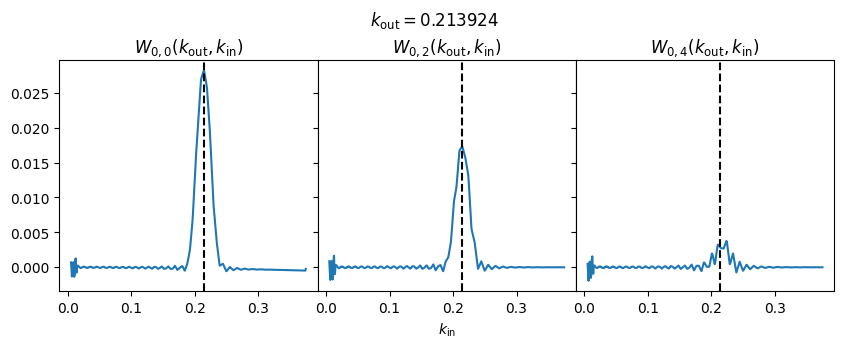

In [52]:
from meer21cm.plot import plot_discrete_shell_window_row

# fine k-bin
plot_discrete_shell_window_row(mat_smooth3_alt,8);

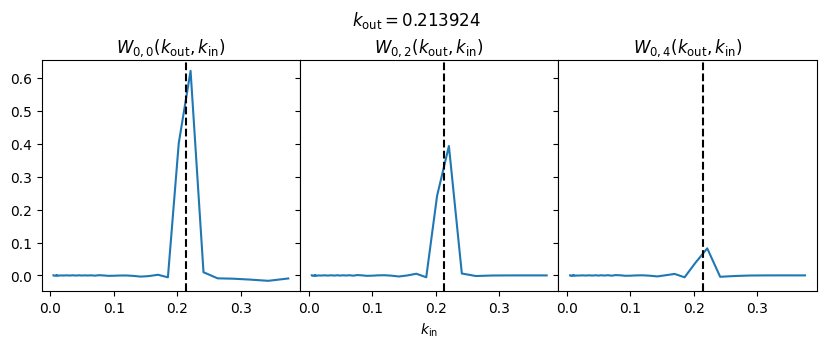

In [53]:
# log spaced k-bin
plot_discrete_shell_window_row(mat_smooth3,8);


You can see that even though there is oversampling in the fine linear k-bin, it is sampling enough to produce fine structures and correct normalisation. In the coarse log-space, it is simply not sampling enough.

In this case of 500 bins, log or linear does not matter that much:

In [56]:
# the dense theory k-grids in linear spacing
k_in_alt2 = np.geomspace(max(float(k1dbins[0]) * 0.5, 1e-3), float(k1dbins[-1]) * 1.5, 500)

# only look at very fine k-bins
mat_smooth3_alt2 = swe3.build_window_matrix(
    k_in_alt2,
    shell_map=shell,
    continuous="smooth",
    n_fftlog=256,
    n_k_eval=128,
)

# get the unconvolved theory
with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)
    cont_fine_alt2 = mock.get_theory_multipoles_kmu(k_in_alt2, ells=ells, nmu=64, which="auto_1")


P_win_smooth3_alt2 = mat_smooth3_alt2.apply(cont_fine_alt2["P_ell"])

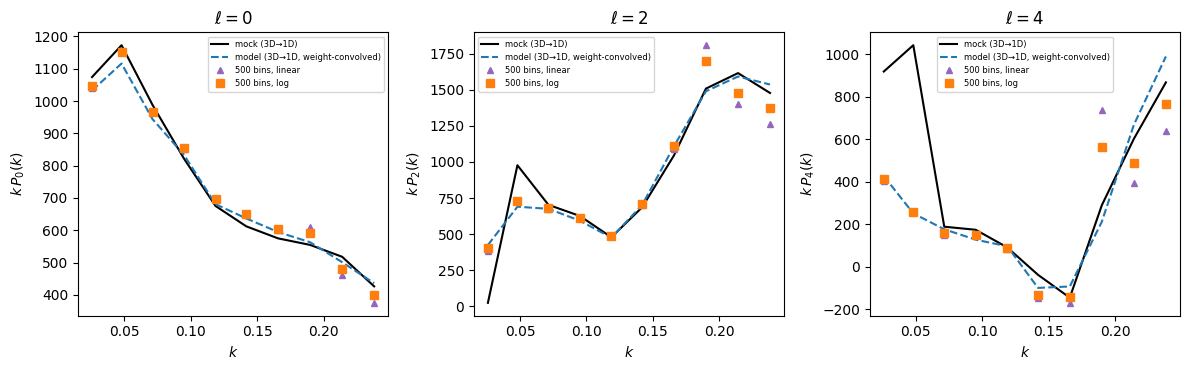

In [58]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.8), sharex=True)
for ax, ell in zip(axes, ells):
    ax.plot(keff_disc, P_disc_mock[ell] * keff_disc, "k-", lw=1.5, label="mock (3D→1D)")
    ax.plot(
        keff_disc,
        P_disc_model[ell] * keff_disc,
        "C0--",
        lw=1.5,
        label=r"model (3D→1D, weight-convolved)",
    )
    ax.plot(
        mat_smooth3_alt.k_out,
        P_win_smooth3_alt[ell] * mat_smooth3_alt.k_out,
        "C4^",
        ms=5,
        label=r"500 bins, linear",
    )
    ax.plot(
        mat_smooth3_alt2.k_out,
        P_win_smooth3_alt2[ell] * mat_smooth3_alt2.k_out,
        "C1s",
        label=r"500 bins, log",
    )
    ax.set_xlabel(r"$k$")
    ax.set_ylabel(r"$k\,P_%d(k)$" % ell)
    ax.legend(fontsize=6)
    ax.set_title(r"$\ell=%d$" % ell)
fig.tight_layout()
